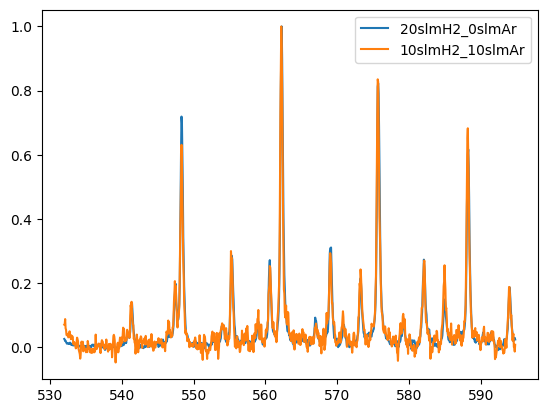

In [15]:
import pickle
import sif_parser
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from toddler.data.spectrum import Spectrum
import wedme

dir_data = Path("/Users/martijn/Library/CloudStorage/OneDrive-MaastrichtUniversity/Data/250114/")

def get_data_for_meas(f_fg):
    f_bg = f_fg.with_stem(f_fg.stem + "_bg")

    s_fg = Spectrum.from_file(f_fg, new_axes=True).median(axis=2)
    s_fg._axis_lambda = 0

    s_bg = Spectrum.from_file(f_bg, new_axes=True).median(axis=2)
    s_bg._axis_lambda = 0

    s_raman = s_fg - s_bg

    # plt.figure()
    # plt.plot(s_fg.lambdanm, s_fg.sdata, label="fg")
    # plt.plot(s_bg.lambdanm, s_bg.sdata, label="bg")
    # plt.plot(s_raman.lambdanm, s_raman.sdata, label="fg-bg") 

    return s_raman.squeeze()


s_20slmH2_0slmAr = get_data_for_meas(dir_data / "01_200mbar_20slmH2_0slmAr_1000W_g2l532.sif")
s_10slmH2_10slmAr = get_data_for_meas(dir_data / "01_200mbar_10slmH2_10slmAr_1000W_g2l532.sif")

plt.figure()
plt.plot(s_20slmH2_0slmAr.lambdanm, s_20slmH2_0slmAr.c.normalize(axis=0).sdata, label="20slmH2_0slmAr")
plt.plot(s_10slmH2_10slmAr.lambdanm, s_10slmH2_10slmAr.c.normalize(axis=0).sdata, label="10slmH2_10slmAr")
plt.legend()
plt.show()

In [ ]:
from lmfit import minimize, Parameters, fit_report
from ramlab.simulate.linespreadfunction.functions import gaussian, voigt, lorentzian, rect, martijnian
from ramlab.molecules.H2 import H2
import matplotlib.pyplot as plt
import wedme.apply.dev
import numpy as np
from ramlab.molecules.calculated_linelist_molecule import CalculatedLinelistMolecule
from ramlab.simulate import simulate, simulate_raw
import lmfit
import pickle
import sif_parser
import numpy as np
import matplotlib.pyplot as plt

from ttictoc import tic,toc


from ramlab.fit.modifiers import *
from ramlab.molecules.polarisation import Polarisation


M = CalculatedLinelistMolecule(H2)
transitions = M.get_all_transitions(laser_wavelength=532e-9, force_recalculate=True)
transitions = transitions[transitions.dv == 0]
transitions = transitions[transitions.dJ == 2]
# transitions = transitions[transitions.initial_J < 5]
transitions = transitions[transitions.crosssection != np.nan]

I_const_par = M.get_intensity_constant(transitions, laser_wavelength=532e-9, polarisation=Polarisation.PARALLEL)
I_const_per = M.get_intensity_constant(transitions, laser_wavelength=532e-9, polarisation=Polarisation.PERPENDICULAR)
I_var = M.get_intensity_variable(transitions, T=300)

I = (I_const_par + I_const_per) * I_var
I /= np.nanmax(I)
dnu = M.dE(transitions)


fitParameters = Parameters()
fitParameters.add("A", value=1, min=0.9, max=1.1, vary=True)
fitParameters.add("T", value=3000, vary=True)
fitParameters.add("w_g", value=3, min=0, vary=True)
fitParameters.add("w_l", value=4, min=0, vary=True)

wavelengthCorrection = WavelengthAxisCorrection(1)
wavelengthCorrection.add_parameters(fitParameters, [0.72105250, -0.13505485], vary=False)

def spectral_fit_residuals(pars: Parameters, meas, I_const_per, I_const_par, test=False):
    tic()
    A = pars['A']
    T = pars['T']
    w_g = pars['w_g']
    w_l = pars['w_l']

    meas = MeasurementSpectrum(meas)
    meas = wavelengthCorrection.modify(meas, pars)

    meas = meas.data
    dnu_meas = meas.dnu()/1e2, 
    I_meas = meas.c.normalize(axis=0).sdata


    I_var = M.get_intensity_variable(transitions, T=T)
    # I_stick_sim = (I_const_per) * I_var
    I_stick_sim = (I_const_per + I_const_par) * I_var
    I_stick_sim /= np.nanmax(I_stick_sim)

    dnu_stick = transitions.vacuum_wavenumber

    I_sim_broad = simulate_raw(dnu_meas, dnu_stick, I_stick_sim, w_g, w_l)
    I_sim_broad *= A / np.nanmax(I_sim_broad)

    # print(f"Execution time: {toc()*1e3:.0f}ms")

    if test is True:
        return I_sim_broad

    return (I_sim_broad - I_meas)**2

# s = s_20slmH2_0slmAr # T=3208 +/- 13
s = s_10slmH2_10slmAr # T=3478 +/- 25
out = minimize(spectral_fit_residuals, fitParameters, args=(s.c.normalize(axis=0), I_const_per, I_const_par))
spectral_fit_residuals(fitParameters, s.c.normalize(axis=0), I_const_per, I_const_par, test=True)

print(fit_report(out))

Generating linelist file...
Calculating cross-section
Calculating cross-section
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 71
    # data points      = 1024
    # variables        = 4
    chi-square         = 0.00549138
    reduced chi-square = 5.3837e-06
    Akaike info crit   = -12419.3135
    Bayesian info crit = -12399.5876
[[Variables]]
    A:                    0.90535145 +/- 0.00592840 (0.65%) (init = 1)
    T:                    3478.07628 +/- 25.2081506 (0.72%) (init = 3000)
    w_g:                  3.55690168 +/- 0.24264033 (6.82%) (init = 3)
    w_l:                  4.06410865 +/- 0.32366819 (7.96%) (init = 4)
    lambda_correction_0:  0.7210525 (fixed)
    lambda_correction_1: -0.1350549 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(w_g, w_l) = -0.9638
    C(A, w_g)   = -0.4793
    C(A, T)     = -0.3202
    C(A, w_l)   = +0.3071


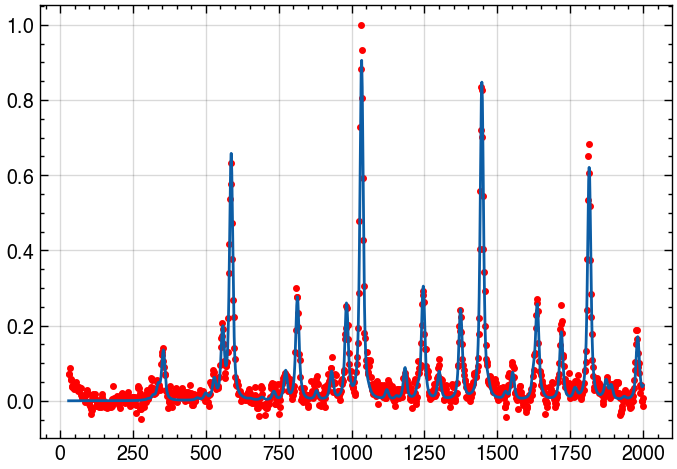

In [48]:
ver2 = wavelengthCorrection.modify(MeasurementSpectrum(s.c), out.params).data

plt.figure()
plt.plot(ver2.dnu()/1e2, ver2.c.normalize(axis=0).sdata, 'r.')
plt.plot(ver2.dnu()/1e2, spectral_fit_residuals(out.params, s.c.normalize(axis=0), I_const_per, I_const_par, test=True))
# plt.xlim(4000, 4200)